In [117]:
from sklearn.datasets import make_classification
import numpy as np
X,y = make_classification(n_samples=100,n_features=2,n_informative=1,n_redundant=0,n_classes=2,n_clusters_per_class=1,
                          random_state=41,hypercube=False,class_sep=10)
import matplotlib.pyplot as plt


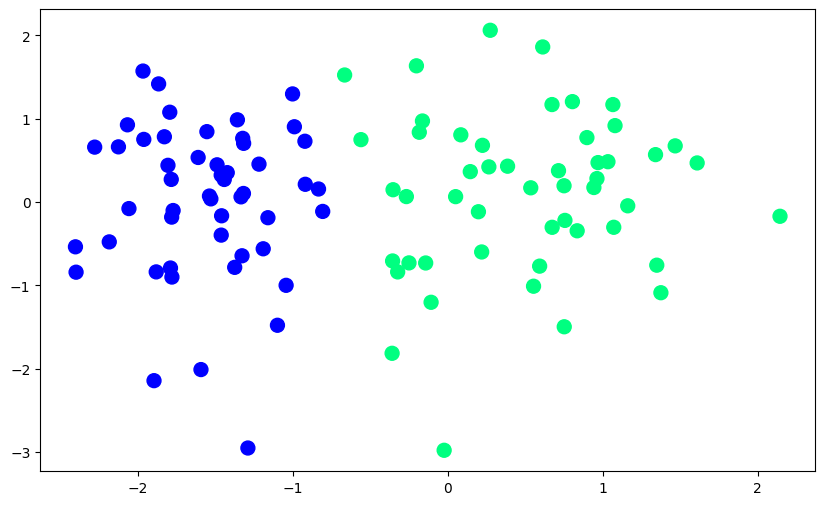

In [6]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

Perceptron Trick

In [92]:
def step(z):
  return 1 if z > 0 else 0

In [104]:
def Perceptron(X,y):
  X = np.insert(X,0,1,axis=1)
  weights = np.ones(X.shape[1])
  lr = 0.1
  for i in range(500):
    j = np.random.randint(0,100)
    y_hat = step(np.dot(X[j],weights))
    weights = weights + lr * (y[j] - y_hat) * X[j]
  return weights[0] , weights[1:]

In [105]:
intercept_,coef_ =  Perceptron(X,y)

In [106]:
intercept_

np.float64(1.0)

In [107]:
coef_

array([1.3930767 , 0.04442348])

In [111]:
# m = (-A/B) , b = -(C / B)
m = -(coef_[0] / coef_[1])
b = -(intercept_ / coef_[1])

In [112]:
x_input = np.linspace(-3,3,100)
y_input = m * x_input + b

(-3.0, 2.0)

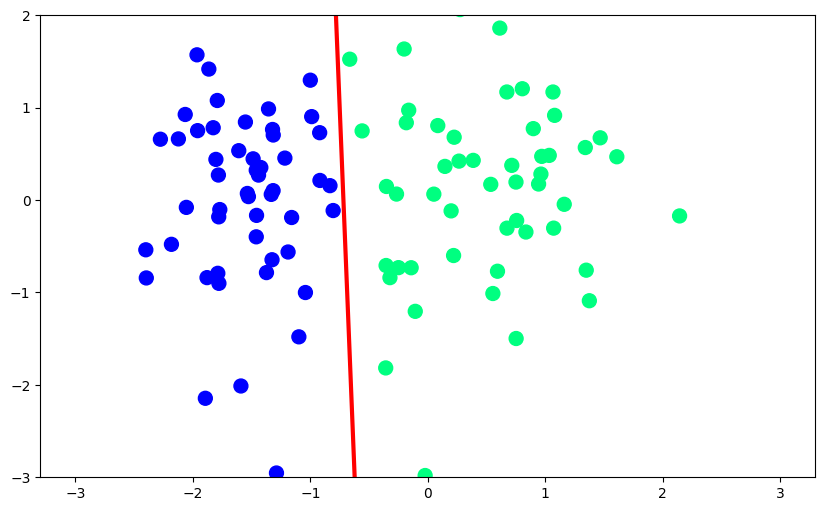

In [113]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [118]:
def Perceptron(X,y):
  m = []
  b = []
  X = np.insert(X,0,1,axis=1)
  weights = np.ones(X.shape[1])
  lr = 0.1
  for i in range(200):
    j = np.random.randint(0,100)
    y_hat = step(np.dot(X[j],weights))
    weights = weights + lr * (y[j] - y_hat) * X[j]
    m.append(-(weights[1] / weights[2]))
    b.append(-(weights[0] / weights[2]))
  return m , b

In [119]:
m , b = Perceptron(X,y)

In [138]:
%matplotlib inline  # Use inline for better animation display
from IPython.display import HTML
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

UsageError: unrecognized arguments: # Use inline for better animation display


In [139]:
fig,ax = plt.subplots(figsize=(9,5))
x_i = np.arange(-3,3,0.1)
y_i = x_i * m[0] + b[0]
ax.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
line , = ax.plot(x_i , x_i*m[0] + b[0],'r-',linewidth=2)
plt.ylim(-3,3)
def update(i):
  label = 'epoch {0}'.format(i+1)
  line.set_ydata(x_i*m[i]+b[i])
  ax.set_xlabel(label)
  return line,ax
anim = animation.FuncAnimation(fig,update,repeat=True,frames=200,interval=100)
HTML(anim.to_html5_video())

<IPython.core.display.Javascript object>

/usr/local/lib/python3.11/dist-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


In [136]:
from IPython.display import HTML

In [137]:
!apt-get install ffmpeg

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.


In [140]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()
lor.fit(X,y)

LogisticRegression()

In [141]:
m = -(lor.coef_[0][0] / lor.coef_[0][1])
b = -(lor.intercept_[0] / lor.coef_[0][1])

In [142]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b

In [148]:
%matplotlib inline

(-3.0, 2.0)

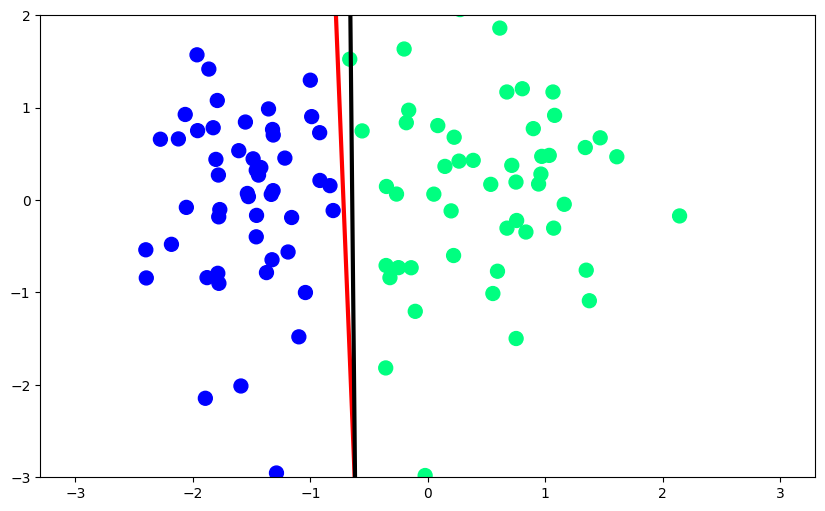

In [151]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)
